# Final IEQ Extra Trees model

This notebook builds the final Extra Trees model after the fine-tuning audit. It keeps the original three-class IEQ satisfaction target and uses only the retained strategies:

1. ten-fold stratified classification validation,
2. imputation-indicator columns,
3. class-weight and decision-threshold tuning.

The threshold step is evaluated safely with nested inner folds. The final cell fits the selected model on all rows and saves the trained pipeline plus metadata for downstream use.

In [1]:
from __future__ import annotations

import builtins
import json
import sys
import time
from pathlib import Path
from typing import Callable

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score, mean_absolute_error, recall_score
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

STYLE_DIR = Path.cwd()
for root in [Path.cwd(), *Path.cwd().parents]:
    candidate = root / "03_Code" / "ieq_paper" / "01_notebook"
    if (candidate / "paper_style.py").exists():
        STYLE_DIR = candidate.resolve()
        break
if str(STYLE_DIR) not in sys.path:
    sys.path.insert(0, str(STYLE_DIR))

from paper_style import COLORS as PAPER_COLORS, apply_paper_style, plot_confusion_matrix, save_figure, style_axes

apply_paper_style()
display = getattr(builtins, "display", print)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)


In [2]:
SEED = 20260507
N_SPLITS = 10
THRESHOLD_INNER_SPLITS = 3
N_JOBS = 1

TARGET = "IEQ satisfaction 3-class"
DROP_FROM_FEATURES = [TARGET, "TimeVote"]
CLASS_ORDER = ["dissatisfied", "neutral", "satisfied"]
CLASS_TO_NUMBER = {label: i for i, label in enumerate(CLASS_ORDER)}
REPORT_METRICS = ["macro_f1", "accuracy", "balanced_accuracy", "ordinal_mae"]
# Best manual class-weight setting retained from the fine-tuning notebook.
FINAL_CLASS_WEIGHT = {"dissatisfied": 3.0, "neutral": 2.0, "satisfied": 1.0}

PROBABILITY_MULTIPLIER_GRID = [
    {"dissatisfied": m0, "neutral": m1, "satisfied": 1.0}
    for m0 in [1.0, 1.2, 1.5, 2.0, 2.5]
    for m1 in [1.0, 1.2, 1.5, 2.0]
]

FEATURE_IMPORTANCE_TOP_N = 20
PERMUTATION_REPEATS = 5
SHAP_SAMPLE_SIZE = 1000


## Paths and data

The model-ready dataset supplies the predictors and three-class target. The clean dataset is used only to identify which predictor values had been imputed before modeling.

In [3]:
def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else start
    for candidate in [start, *start.parents]:
        if (candidate / "02_Datasets").exists() and (candidate / "06_Paper").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing 02_Datasets and 06_Paper.")


PROJECT_ROOT = find_project_root()
DATASET_PATH = PROJECT_ROOT / "02_Datasets" / "model_ready" / "ieq_model_dataset.xlsx"
CLEAN_DATASET_PATH = PROJECT_ROOT / "02_Datasets" / "clean" / "ieq_clean_dataset.xlsx"
BEST_PARAMS_PATH = PROJECT_ROOT / "03_Code" / "ieq_paper" / "02_outputs" / "tables" / "hyperparameter_tuning_best_params.csv"
OUTPUT_DIR = PROJECT_ROOT / "03_Code" / "ieq_paper" / "02_outputs" / "final_extra_trees_model"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "model"
PAPER_FIGURE_DIR = PROJECT_ROOT / "04_Figures"

for directory in [TABLE_DIR, FIGURE_DIR, MODEL_DIR, PAPER_FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

model_data = pd.read_excel(DATASET_PATH)
clean_data = pd.read_excel(CLEAN_DATASET_PATH)

if len(model_data) != len(clean_data):
    raise ValueError("Model-ready and clean datasets must have the same row count.")

feature_columns = [column for column in model_data.columns if column not in DROP_FROM_FEATURES]
X_base = model_data[feature_columns].copy()
y = model_data[TARGET].astype(str)

best_params_table = pd.read_csv(BEST_PARAMS_PATH)
best_params = {
    row["model"]: json.loads(row["best_params_json"])
    for _, row in best_params_table.iterrows()
}
EXTRA_TREES_PARAMS = best_params["Extra Trees"]

display(
    pd.DataFrame(
        [
            {
                "rows": len(X_base),
                "base_predictors": X_base.shape[1],
                "target": TARGET,
                "cv_splits": N_SPLITS,
            }
        ]
    )
)
display(y.value_counts().reindex(CLASS_ORDER).rename("rows").to_frame())
display(pd.DataFrame([{"model": "Extra Trees", **EXTRA_TREES_PARAMS}]))

,rows,base_predictors,target,cv_splits
0,6834,20,IEQ satisfaction 3-class,10


,rows
IEQ satisfaction 3-class,
dissatisfied,484
neutral,1855
satisfied,4495


,model,model__bootstrap,model__class_weight,model__criterion,model__max_depth,model__max_features,model__max_samples,model__min_samples_leaf,model__min_samples_split,model__n_estimators
0,Extra Trees,True,balanced,entropy,None,None,0.9,2,10,500


## Imputation-indicator columns

The final predictor matrix adds binary flags for predictors that were missing in the clean dataset before imputation, plus a row-level count of imputed predictors.

In [4]:
def add_missingness_indicators(frame: pd.DataFrame, clean_frame: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    output = frame.copy()
    indicator_columns = []
    for column in frame.columns:
        if column not in clean_frame.columns:
            continue
        missing_mask = clean_frame[column].isna()
        if not missing_mask.any():
            continue
        indicator_name = f"{column}_was_imputed"
        output[indicator_name] = missing_mask.astype(int).to_numpy()
        indicator_columns.append(indicator_name)

    if indicator_columns:
        output["n_imputed_predictors"] = output[indicator_columns].sum(axis=1)
        indicator_columns.append("n_imputed_predictors")

    return output, indicator_columns


X_final, missingness_indicator_columns = add_missingness_indicators(X_base, clean_data)

print("Final predictor count:", X_final.shape[1])
display(pd.Series(missingness_indicator_columns, name="indicator").to_frame())

Final predictor count: 31


,indicator
0,CLO_was_imputed
1,Lighting_was_imputed
2,Sound_was_imputed
3,Age_was_imputed
4,Gender_was_imputed
5,LocationBack_was_imputed
6,LocationFront_was_imputed
7,LocationLeft_was_imputed
8,LocationMiddle_was_imputed
9,Ttrend_was_imputed


## Shared model functions

In [5]:
def dense_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    numeric = X.select_dtypes(include=["number"]).columns.tolist()
    categorical = [column for column in X.columns if column not in numeric]
    transformers = []
    if numeric:
        transformers.append(("numeric", StandardScaler(), numeric))
    if categorical:
        transformers.append(("categorical", dense_one_hot_encoder(), categorical))
    return ColumnTransformer(transformers=transformers)


def make_pipeline(X: pd.DataFrame, params: dict, *, seed: int, class_weight: str | dict[str, float] | None = None) -> Pipeline:
    pipeline = Pipeline(
        steps=[
            ("preprocess", make_preprocessor(X)),
            ("model", ExtraTreesClassifier(n_jobs=N_JOBS, random_state=seed)),
        ]
    )
    pipeline.set_params(**params)
    if class_weight is not None:
        pipeline.set_params(model__class_weight=class_weight)
    return pipeline


def ordinal_mae(y_true: pd.Series, y_pred: pd.Series | np.ndarray) -> float:
    true_values = pd.Series(y_true).map(CLASS_TO_NUMBER).to_numpy()
    pred_values = pd.Series(y_pred).map(CLASS_TO_NUMBER).to_numpy()
    return float(mean_absolute_error(true_values, pred_values))


def metric_row(y_true: pd.Series, y_pred: pd.Series | np.ndarray) -> dict[str, float]:
    return {
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "ordinal_mae": ordinal_mae(y_true, y_pred),
    }


def per_class_recall_row(y_true: pd.Series, y_pred: pd.Series | np.ndarray) -> dict[str, float]:
    recalls = recall_score(y_true, y_pred, labels=CLASS_ORDER, average=None, zero_division=0)
    return {f"recall_{label}": float(value) for label, value in zip(CLASS_ORDER, recalls)} # type: ignore


def class_ordered_probabilities(pipeline: Pipeline, X: pd.DataFrame) -> np.ndarray:
    raw_probabilities = pipeline.predict_proba(X)
    output = np.zeros((len(X), len(CLASS_ORDER)))
    class_to_column = {label: index for index, label in enumerate(pipeline.named_steps["model"].classes_)}
    for output_column, label in enumerate(CLASS_ORDER):
        if label in class_to_column:
            output[:, output_column] = raw_probabilities[:, class_to_column[label]]
    return output


def labels_from_probabilities(probabilities: np.ndarray) -> np.ndarray:
    return np.array(CLASS_ORDER)[np.argmax(probabilities, axis=1)]


def apply_probability_multipliers(probabilities: np.ndarray, multipliers: dict[str, float]) -> np.ndarray:
    multiplier_array = np.array([multipliers[label] for label in CLASS_ORDER], dtype=float)
    adjusted = probabilities * multiplier_array
    row_sums = adjusted.sum(axis=1, keepdims=True)
    return np.divide(adjusted, row_sums, out=np.zeros_like(adjusted), where=row_sums != 0)


def select_probability_multipliers(
    probabilities: np.ndarray,
    y_true: pd.Series,
    multiplier_grid: list[dict[str, float]],
) -> tuple[dict[str, float], pd.DataFrame]:
    rows = []
    for multipliers in multiplier_grid:
        adjusted_probabilities = apply_probability_multipliers(probabilities, multipliers)
        y_pred = labels_from_probabilities(adjusted_probabilities)
        rows.append(
            {
                "multiplier_dissatisfied": multipliers["dissatisfied"],
                "multiplier_neutral": multipliers["neutral"],
                "multiplier_satisfied": multipliers["satisfied"],
                **metric_row(y_true, y_pred),
                **per_class_recall_row(y_true, y_pred),
            }
        )
    grid_results = pd.DataFrame(rows).sort_values(
        ["macro_f1", "balanced_accuracy", "ordinal_mae"],
        ascending=[False, False, True],
    )
    best = grid_results.iloc[0]
    return (
        {
            "dissatisfied": float(best["multiplier_dissatisfied"]),
            "neutral": float(best["multiplier_neutral"]),
            "satisfied": float(best["multiplier_satisfied"]),
        },
        grid_results,
    )


def summarize_folds(folds: pd.DataFrame) -> pd.DataFrame:
    group_columns = ["variant", "cv_splits", "rows", "predictors", "class_weight", "threshold_tuning"]
    metric_columns = REPORT_METRICS + [
        "recall_dissatisfied",
        "recall_neutral",
        "recall_satisfied",
        "fit_seconds",
        "predict_seconds",
        "total_seconds",
    ]
    summary = folds.groupby(group_columns, dropna=False)[metric_columns].agg(["mean", "std"]).reset_index()
    summary.columns = [
        "_".join(column).rstrip("_") if isinstance(column, tuple) else column
        for column in summary.columns
    ]
    return summary

## Ten-fold validation of the final strategy

This validation trains one final strategy: imputation-indicator predictors, the selected class-weight setting, and nested decision-threshold tuning. Class-specific probability multipliers are selected only from inner folds of the outer training data, then applied once to the held-out outer validation fold.

In [6]:
def inner_oof_probabilities(
    X_train_outer: pd.DataFrame,
    y_train_outer: pd.Series,
    *,
    outer_fold: int,
    class_weight: dict[str, float],
) -> tuple[np.ndarray, pd.Series]:
    probabilities = np.zeros((len(X_train_outer), len(CLASS_ORDER)))
    inner_cv = StratifiedKFold(
        n_splits=THRESHOLD_INNER_SPLITS,
        shuffle=True,
        random_state=SEED + 1000 + outer_fold,
    )
    for inner_fold, (inner_train_index, inner_valid_index) in enumerate(
        inner_cv.split(X_train_outer, y_train_outer),
        start=1,
    ):
        X_inner_train = X_train_outer.iloc[inner_train_index].copy()
        X_inner_valid = X_train_outer.iloc[inner_valid_index].copy()
        y_inner_train = y_train_outer.iloc[inner_train_index].copy()
        pipeline = make_pipeline(
            X_train_outer,
            EXTRA_TREES_PARAMS,
            seed=SEED + outer_fold * 100 + inner_fold,
            class_weight=class_weight,
        )
        pipeline.fit(X_inner_train, y_inner_train)
        probabilities[inner_valid_index, :] = class_ordered_probabilities(pipeline, X_inner_valid)
    return probabilities, y_train_outer.reset_index(drop=True)


def evaluate_nested_threshold_cv(
    X: pd.DataFrame,
    y_values: pd.Series,
    *,
    variant: str,
    class_weight: dict[str, float],
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    rows = []
    predictions = []
    grid_tables = []
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

    for fold, (train_index, test_index) in enumerate(cv.split(X, y_values), start=1):
        X_train, X_test = X.iloc[train_index].copy(), X.iloc[test_index].copy()
        y_train, y_test = y_values.iloc[train_index].copy(), y_values.iloc[test_index].copy()

        inner_probabilities, inner_y = inner_oof_probabilities(
            X_train.reset_index(drop=True),
            y_train.reset_index(drop=True),
            outer_fold=fold,
            class_weight=class_weight,
        )
        selected_multipliers, grid_results = select_probability_multipliers(
            inner_probabilities,
            inner_y,
            PROBABILITY_MULTIPLIER_GRID,
        )
        grid_results = grid_results.copy()
        grid_results["outer_fold"] = fold
        grid_tables.append(grid_results)

        pipeline = make_pipeline(X, EXTRA_TREES_PARAMS, seed=SEED + 2000 + fold, class_weight=class_weight)

        start = time.perf_counter()
        pipeline.fit(X_train, y_train)
        fit_seconds = time.perf_counter() - start

        start = time.perf_counter()
        probabilities = class_ordered_probabilities(pipeline, X_test)
        adjusted_probabilities = apply_probability_multipliers(probabilities, selected_multipliers)
        y_pred = pd.Series(labels_from_probabilities(adjusted_probabilities), index=y_test.index)
        predict_seconds = time.perf_counter() - start

        rows.append(
            {
                "variant": variant,
                "fold": fold,
                "cv_splits": N_SPLITS,
                "rows": len(X),
                "predictors": X.shape[1],
                "class_weight": str(class_weight),
                "threshold_tuning": "nested_inner_cv",
                "multiplier_dissatisfied": selected_multipliers["dissatisfied"],
                "multiplier_neutral": selected_multipliers["neutral"],
                "multiplier_satisfied": selected_multipliers["satisfied"],
                "fit_seconds": fit_seconds,
                "predict_seconds": predict_seconds,
                "total_seconds": fit_seconds + predict_seconds,
                **metric_row(y_test, y_pred),
                **per_class_recall_row(y_test, y_pred),
            }
        )
        predictions.append(
            pd.DataFrame(
                {
                    "variant": variant,
                    "fold": fold,
                    "row_id": y_test.index,
                    "y_true": y_test.to_numpy(),
                    "y_pred": y_pred.to_numpy(),
                    "prob_dissatisfied": probabilities[:, 0],
                    "prob_neutral": probabilities[:, 1],
                    "prob_satisfied": probabilities[:, 2],
                    "adjusted_prob_dissatisfied": adjusted_probabilities[:, 0],
                    "adjusted_prob_neutral": adjusted_probabilities[:, 1],
                    "adjusted_prob_satisfied": adjusted_probabilities[:, 2],
                    "multiplier_dissatisfied": selected_multipliers["dissatisfied"],
                    "multiplier_neutral": selected_multipliers["neutral"],
                    "multiplier_satisfied": selected_multipliers["satisfied"],
                }
            )
        )

    return pd.DataFrame(rows), pd.concat(predictions, ignore_index=True), pd.concat(grid_tables, ignore_index=True)

In [7]:
final_threshold_folds, final_threshold_predictions, final_threshold_grid = evaluate_nested_threshold_cv(
    X_final,
    y,
    variant="final_imputation_class_weight_threshold_10fold",
    class_weight=FINAL_CLASS_WEIGHT,
)

validation_folds = final_threshold_folds.copy()
validation_predictions = final_threshold_predictions.copy()
validation_summary = summarize_folds(validation_folds)

display_columns = [
    "variant",
    "macro_f1_mean",
    "accuracy_mean",
    "balanced_accuracy_mean",
    "ordinal_mae_mean",
    "recall_dissatisfied_mean",
    "recall_neutral_mean",
    "recall_satisfied_mean",
]
validation_article_table = validation_summary[display_columns].copy()
for column in validation_article_table.select_dtypes(include=["float"]).columns:
    validation_article_table[column] = validation_article_table[column].round(6)

display(validation_article_table)
display(final_threshold_folds[["fold", "multiplier_dissatisfied", "multiplier_neutral", "multiplier_satisfied"]])

,variant,macro_f1_mean,accuracy_mean,balanced_accuracy_mean,ordinal_mae_mean,recall_dissatisfied_mean,recall_neutral_mean,recall_satisfied_mean
0,final_imputation_class_weight_threshold_10fold,0.622908,0.740414,0.624758,0.291044,0.433376,0.616199,0.824701


,fold,multiplier_dissatisfied,multiplier_neutral,multiplier_satisfied
0,1,2.0,1.2,1.0
1,2,1.5,1.2,1.0
2,3,1.5,1.2,1.0
3,4,1.5,1.2,1.0
4,5,1.2,1.2,1.0
5,6,2.0,1.2,1.0
6,7,1.2,1.2,1.0
7,8,1.5,1.2,1.0
8,9,1.5,1.0,1.0
9,10,1.0,1.2,1.0


## Confusion matrix

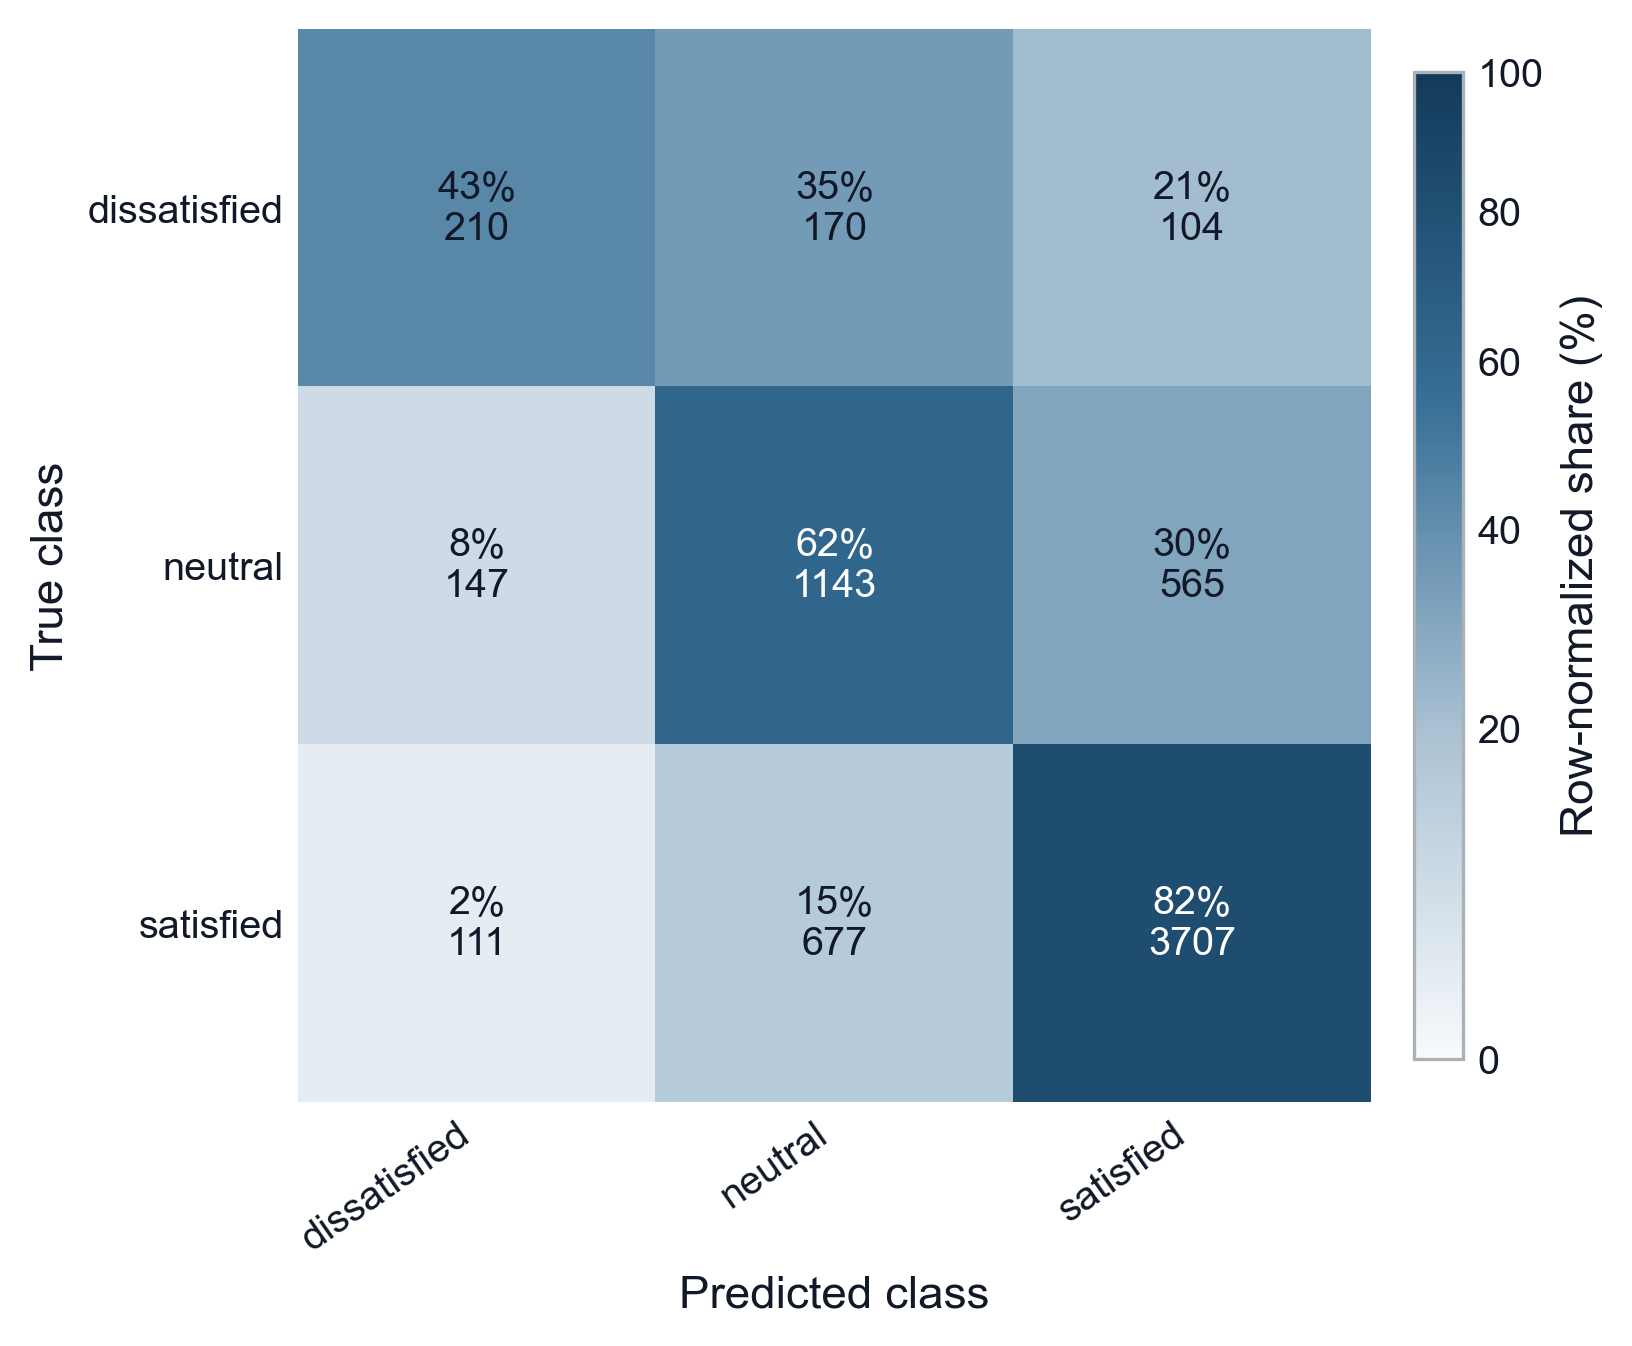

In [8]:
def confusion_matrix_for_variant(predictions: pd.DataFrame, variant: str) -> pd.DataFrame:
    selected = predictions[predictions["variant"].eq(variant)]
    matrix = confusion_matrix(selected["y_true"], selected["y_pred"], labels=CLASS_ORDER)
    return pd.DataFrame(matrix, index=CLASS_ORDER, columns=CLASS_ORDER)


final_variant = "final_imputation_class_weight_threshold_10fold"
matrix = confusion_matrix_for_variant(validation_predictions, final_variant)
confusion_table = (
    matrix.reset_index(names="true_label")
    .assign(variant=final_variant)
    .melt(
        id_vars=["variant", "true_label"],
        var_name="predicted_label",
        value_name="count",
    )
)

fig, ax = plt.subplots(figsize=(5.2, 4.5), constrained_layout=True)
image, colorbar_label = plot_confusion_matrix(
    ax,
    matrix,
    labels=CLASS_ORDER,
    display_labels=CLASS_ORDER,
    title=None,
    xtick_rotation=35,
    annotation_fontsize=9.5,
)
colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
colorbar.set_label(colorbar_label)
plt.show()


## Fit and save the final all-row model

The validation above uses nested threshold tuning for an unbiased estimate. For the saved all-row model, the final probability multipliers are selected from ten-fold out-of-fold probabilities on the full training data, then the Extra Trees pipeline is fitted once on all rows.

In [9]:
full_oof_probabilities = np.zeros((len(X_final), len(CLASS_ORDER)))
full_cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED + 9000)

for fold, (train_index, valid_index) in enumerate(full_cv.split(X_final, y), start=1):
    X_train, X_valid = X_final.iloc[train_index].copy(), X_final.iloc[valid_index].copy()
    y_train = y.iloc[train_index].copy()
    pipeline = make_pipeline(X_final, EXTRA_TREES_PARAMS, seed=SEED + 9000 + fold, class_weight=FINAL_CLASS_WEIGHT)
    pipeline.fit(X_train, y_train)
    full_oof_probabilities[valid_index, :] = class_ordered_probabilities(pipeline, X_valid)

final_probability_multipliers, final_multiplier_grid = select_probability_multipliers(
    full_oof_probabilities,
    y.reset_index(drop=True),
    PROBABILITY_MULTIPLIER_GRID,
)

final_pipeline = make_pipeline(X_final, EXTRA_TREES_PARAMS, seed=SEED, class_weight=FINAL_CLASS_WEIGHT)
final_pipeline.fit(X_final, y)

final_training_probabilities = class_ordered_probabilities(final_pipeline, X_final)
final_training_adjusted_probabilities = apply_probability_multipliers(
    final_training_probabilities,
    final_probability_multipliers,
)
final_training_pred = pd.Series(labels_from_probabilities(final_training_adjusted_probabilities), index=y.index)

final_training_metrics = {
    **metric_row(y, final_training_pred),
    **per_class_recall_row(y, final_training_pred),
}

metadata = {
    "target": TARGET,
    "class_order": CLASS_ORDER,
    "base_feature_columns": feature_columns,
    "missingness_indicator_columns": missingness_indicator_columns,
    "final_feature_columns": X_final.columns.tolist(),
    "extra_trees_params": EXTRA_TREES_PARAMS,
    "final_class_weight": FINAL_CLASS_WEIGHT,
    "final_probability_multipliers": final_probability_multipliers,
    "cv_splits_for_validation": N_SPLITS,
    "threshold_inner_splits_for_validation": THRESHOLD_INNER_SPLITS,
    "seed": SEED,
    "training_rows": len(X_final),
    "training_metrics_not_cv": final_training_metrics,
}

model_path = MODEL_DIR / "ieq_final_extra_trees_pipeline.joblib"
metadata_path = MODEL_DIR / "ieq_final_extra_trees_metadata.json"
validation_folds_path = TABLE_DIR / "ieq_final_extra_trees_10fold_folds.csv"
validation_summary_path = TABLE_DIR / "ieq_final_extra_trees_10fold_summary.csv"
validation_predictions_path = TABLE_DIR / "ieq_final_extra_trees_10fold_predictions.csv"
threshold_grid_path = TABLE_DIR / "ieq_final_extra_trees_threshold_inner_grid.csv"
final_multiplier_grid_path = TABLE_DIR / "ieq_final_extra_trees_final_multiplier_grid.csv"
confusion_path = TABLE_DIR / "ieq_final_extra_trees_confusion_matrices.csv"
confusion_figure_png = FIGURE_DIR / "ieq_final_extra_trees_confusion_matrix.png"
confusion_figure_pdf = FIGURE_DIR / "ieq_final_extra_trees_confusion_matrix.pdf"
paper_confusion_figure_png = PAPER_FIGURE_DIR / "final_extra_trees_confusion_matrix.png"
paper_confusion_figure_pdf = PAPER_FIGURE_DIR / "final_extra_trees_confusion_matrix.pdf"

joblib.dump(final_pipeline, model_path)
metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")
validation_folds.to_csv(validation_folds_path, index=False)
validation_summary.to_csv(validation_summary_path, index=False)
validation_predictions.to_csv(validation_predictions_path, index=False)
final_threshold_grid.to_csv(threshold_grid_path, index=False)
final_multiplier_grid.to_csv(final_multiplier_grid_path, index=False)
confusion_table.to_csv(confusion_path, index=False)
fig.savefig(confusion_figure_png, dpi=300, bbox_inches="tight")
fig.savefig(confusion_figure_pdf, bbox_inches="tight")
fig.savefig(paper_confusion_figure_png, dpi=300, bbox_inches="tight")
fig.savefig(paper_confusion_figure_pdf, bbox_inches="tight")

print("Saved model:", model_path)
print("Saved metadata:", metadata_path)
print("Saved validation summary:", validation_summary_path)
print("Saved validation predictions:", validation_predictions_path)
print("Saved confusion figure:", confusion_figure_png)
print("Saved paper confusion figure:", paper_confusion_figure_pdf)
print("Final deployment probability multipliers:", final_probability_multipliers)
print("Training metrics on all rows, not cross-validated:", final_training_metrics)

Saved model: C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\final_extra_trees_model\model\ieq_final_extra_trees_pipeline.joblib
Saved metadata: C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\final_extra_trees_model\model\ieq_final_extra_trees_metadata.json
Saved validation summary: C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\final_extra_trees_model\tables\ieq_final_extra_trees_10fold_summary.csv
Saved validation predictions: C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\final_extra_trees_model\tables\ieq_final_extra_trees_10fold_predictions.csv
Saved confusion figure: C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\final_extra_trees_model\figures\ieq_final_extra_trees_confusion_matrix.png
Saved paper confusion figure: C:\Users\Dell Latitude 5540\OneDrive - 

## Final results overview

This section collects the most important final-model outputs in one place: cross-validated metrics, selected deployment settings, and the out-of-fold confusion matrix.

In [10]:
final_result_overview = validation_summary[
    [
        "variant",
        "cv_splits",
        "rows",
        "predictors",
        "macro_f1_mean",
        "macro_f1_std",
        "accuracy_mean",
        "accuracy_std",
        "balanced_accuracy_mean",
        "balanced_accuracy_std",
        "ordinal_mae_mean",
        "ordinal_mae_std",
        "recall_dissatisfied_mean",
        "recall_neutral_mean",
        "recall_satisfied_mean",
    ]
].copy()
for column in final_result_overview.select_dtypes(include=["float"]).columns:
    final_result_overview[column] = final_result_overview[column].round(6)

deployment_settings = pd.DataFrame(
    [
        {
            "setting": "class_weight",
            "value": json.dumps(FINAL_CLASS_WEIGHT),
        },
        {
            "setting": "probability_multipliers",
            "value": json.dumps(final_probability_multipliers),
        },
        {
            "setting": "feature_count",
            "value": str(X_final.shape[1]),
        },
        {
            "setting": "imputation_indicator_count",
            "value": str(len(missingness_indicator_columns)),
        },
    ]
)

final_confusion_matrix = confusion_matrix_for_variant(
    validation_predictions,
    "final_imputation_class_weight_threshold_10fold",
)

print("Final 10-fold validation metrics")
display(final_result_overview)
print("Deployment settings")
display(deployment_settings)
print("Out-of-fold confusion matrix")
display(final_confusion_matrix)

Final 10-fold validation metrics


,variant,cv_splits,rows,predictors,macro_f1_mean,macro_f1_std,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,ordinal_mae_mean,ordinal_mae_std,recall_dissatisfied_mean,recall_neutral_mean,recall_satisfied_mean
0,final_imputation_class_weight_threshold_10fold,10,6834,31,0.622908,0.028391,0.740414,0.013985,0.624758,0.036136,0.291044,0.018802,0.433376,0.616199,0.824701


Deployment settings


,setting,value
0,class_weight,"{""dissatisfied"": 3.0, ""neutral"": 2.0, ""satisfi..."
1,probability_multipliers,"{""dissatisfied"": 1.5, ""neutral"": 1.2, ""satisfi..."
2,feature_count,31
3,imputation_indicator_count,11


Out-of-fold confusion matrix


,dissatisfied,neutral,satisfied
dissatisfied,210,170,104
neutral,147,1143,565
satisfied,111,677,3707


## Final feature importance

The article figure compares three complementary importance estimates: permutation importance, built-in Extra Trees impurity importance, and mean absolute TreeSHAP importance. The three measures use different units, so each method is normalized to its own maximum for the plot while the bar labels keep the original scale.

In this final notebook, permutation importance is computed on the final all-row fitted model using the training data. It should be read as a model-inspection diagnostic, not as a cross-validated performance estimate.

In [11]:
def original_feature_from_encoded_name(encoded_name: str, original_features: list[str]) -> str:
    name = encoded_name.split("__", 1)[-1]
    for feature in sorted(original_features, key=len, reverse=True):
        if name == feature or name.startswith(f"{feature}_"):
            return feature
    return name


def normalized_importance(values: pd.Series) -> pd.Series:
    clean_values = values.fillna(0).clip(lower=0)
    maximum = clean_values.max()
    if maximum <= 0:
        return pd.Series(np.zeros(len(clean_values)), index=values.index)
    return clean_values / maximum


def final_model_predict_with_thresholds(frame: pd.DataFrame) -> np.ndarray:
    probabilities = class_ordered_probabilities(final_pipeline, frame)
    adjusted_probabilities = apply_probability_multipliers(probabilities, final_probability_multipliers)
    return labels_from_probabilities(adjusted_probabilities)


baseline_training_macro_f1 = f1_score(
    y,
    final_model_predict_with_thresholds(X_final),
    average="macro",
    zero_division=0,
)

permutation_rows = []
rng = np.random.default_rng(SEED + 12000)
for feature in X_final.columns:
    for repeat in range(1, PERMUTATION_REPEATS + 1):
        X_permuted = X_final.copy()
        X_permuted[feature] = rng.permutation(X_permuted[feature].to_numpy())
        permuted_macro_f1 = f1_score(
            y,
            final_model_predict_with_thresholds(X_permuted),
            average="macro",
            zero_division=0,
        )
        permutation_rows.append(
            {
                "feature": feature,
                "repeat": repeat,
                "permutation_macro_f1_drop": baseline_training_macro_f1 - permuted_macro_f1,
            }
        )

permutation_importance_raw = pd.DataFrame(permutation_rows)
permutation_importance = (
    permutation_importance_raw
    .groupby("feature", as_index=False)["permutation_macro_f1_drop"]
    .agg(["mean", "std"])
    .reset_index()
    .rename(
        columns={
            "mean": "permutation_macro_f1_drop_mean",
            "std": "permutation_macro_f1_drop_std",
        }
    )
)

encoded_feature_names = final_pipeline.named_steps["preprocess"].get_feature_names_out()
encoded_builtin = pd.DataFrame(
    {
        "encoded_feature": encoded_feature_names,
        "builtin_importance": final_pipeline.named_steps["model"].feature_importances_,
    }
)
encoded_builtin["feature"] = encoded_builtin["encoded_feature"].apply(
    lambda name: original_feature_from_encoded_name(name, X_final.columns.tolist())
)
builtin_importance = (
    encoded_builtin
    .groupby("feature", as_index=False)
    .agg(builtin_importance=("builtin_importance", "sum"))
    .sort_values("builtin_importance", ascending=False)
)
builtin_importance["builtin_importance_percent"] = (
    builtin_importance["builtin_importance"] / builtin_importance["builtin_importance"].sum() * 100
)

shap_available = False
shap_sample_rows = 0
shap_sample_note = "TreeSHAP not computed"
encoded_shap = pd.DataFrame(columns=["encoded_feature", "shap_mean_abs", "feature"])
shap_importance = pd.DataFrame(columns=["feature", "shap_mean_abs", "shap_importance_percent"])

try:
    import shap

    shap_available = True
    shap_sample_rows = min(SHAP_SAMPLE_SIZE, len(X_final))
    if shap_sample_rows < len(X_final):
        shap_splitter = StratifiedShuffleSplit(n_splits=1, train_size=shap_sample_rows, random_state=SEED)
        shap_index, _ = next(shap_splitter.split(X_final, y))
    else:
        shap_index = np.arange(len(X_final))

    X_shap = X_final.iloc[shap_index]
    y_shap = y.iloc[shap_index]
    shap_sample_distribution = (
        y_shap.value_counts()
        .reindex(CLASS_ORDER)
        .rename_axis("class")
        .reset_index(name="rows")
    )

    X_shap_transformed = final_pipeline.named_steps["preprocess"].transform(X_shap)
    shap_explainer = shap.TreeExplainer(final_pipeline.named_steps["model"])
    shap_values = shap_explainer.shap_values(X_shap_transformed, check_additivity=False)
    if isinstance(shap_values, list):
        shap_mean_abs = np.stack([np.abs(values) for values in shap_values], axis=-1).mean(axis=(0, 2))
    else:
        shap_array = np.asarray(shap_values)
        if shap_array.ndim == 3:
            shap_mean_abs = np.abs(shap_array).mean(axis=(0, 2))
        elif shap_array.ndim == 2:
            shap_mean_abs = np.abs(shap_array).mean(axis=0)
        else:
            raise ValueError(f"Unsupported SHAP array shape: {shap_array.shape}")

    encoded_shap = pd.DataFrame(
        {
            "encoded_feature": encoded_feature_names,
            "shap_mean_abs": shap_mean_abs,
        }
    )
    encoded_shap["feature"] = encoded_shap["encoded_feature"].apply(
        lambda name: original_feature_from_encoded_name(name, X_final.columns.tolist())
    )
    shap_importance = (
        encoded_shap
        .groupby("feature", as_index=False)
        .agg(shap_mean_abs=("shap_mean_abs", "sum"))
        .sort_values("shap_mean_abs", ascending=False)
    )
    shap_importance["shap_importance_percent"] = (
        shap_importance["shap_mean_abs"] / shap_importance["shap_mean_abs"].sum() * 100
    )
    shap_sample_note = "stratified deterministic sample from final model dataset"
except Exception as error:
    shap_sample_distribution = pd.DataFrame(columns=["class", "rows"])
    print("TreeSHAP importance was skipped:", error)

importance_comparison = (
    builtin_importance
    .merge(permutation_importance, on="feature", how="left")
    .merge(shap_importance, on="feature", how="left")
)
for column in ["permutation_macro_f1_drop_mean", "permutation_macro_f1_drop_std", "shap_mean_abs", "shap_importance_percent"]:
    if column not in importance_comparison:
        importance_comparison[column] = np.nan
importance_comparison["permutation_normalized"] = normalized_importance(
    importance_comparison["permutation_macro_f1_drop_mean"]
)
importance_comparison["builtin_normalized"] = normalized_importance(importance_comparison["builtin_importance"])
importance_comparison["shap_normalized"] = normalized_importance(importance_comparison["shap_mean_abs"])
importance_comparison["mean_normalized_importance"] = importance_comparison[
    ["permutation_normalized", "builtin_normalized", "shap_normalized"]
].mean(axis=1)
importance_comparison["shap_sample_rows"] = shap_sample_rows
importance_comparison["shap_sample_note"] = shap_sample_note
importance_comparison = importance_comparison.sort_values("builtin_importance", ascending=False).reset_index(drop=True)
article_importance_comparison = (
    importance_comparison[importance_comparison["feature"].isin(feature_columns)]
    .copy()
    .sort_values("builtin_importance", ascending=False)
    .reset_index(drop=True)
)

importance_comparison_path = TABLE_DIR / "ieq_final_extra_trees_importance_method_comparison.csv"
article_importance_comparison_path = TABLE_DIR / "ieq_final_extra_trees_article_feature_importance.csv"
permutation_raw_path = TABLE_DIR / "ieq_final_extra_trees_permutation_importance_raw.csv"
encoded_builtin_path = TABLE_DIR / "ieq_final_extra_trees_encoded_builtin_importance.csv"
encoded_shap_path = TABLE_DIR / "ieq_final_extra_trees_encoded_shap_importance.csv"
shap_distribution_path = TABLE_DIR / "ieq_final_extra_trees_shap_sample_distribution.csv"

importance_comparison.to_csv(importance_comparison_path, index=False)
article_importance_comparison.to_csv(article_importance_comparison_path, index=False)
permutation_importance_raw.to_csv(permutation_raw_path, index=False)
encoded_builtin.to_csv(encoded_builtin_path, index=False)
encoded_shap.to_csv(encoded_shap_path, index=False)
shap_sample_distribution.to_csv(shap_distribution_path, index=False)

display_columns = [
    "feature",
    "permutation_macro_f1_drop_mean",
    "builtin_importance_percent",
    "shap_importance_percent",
    "mean_normalized_importance",
]
display(article_importance_comparison[display_columns].head(FEATURE_IMPORTANCE_TOP_N).round(6))

,feature,permutation_macro_f1_drop_mean,builtin_importance_percent,shap_importance_percent,mean_normalized_importance
0,Age,0.102616,9.129983,8.151302,0.762287
1,Vote weekday,0.096474,9.113271,7.445264,0.729399
2,CLO,0.077278,7.108044,5.512866,0.563606
3,RH,0.041332,6.371978,3.626603,0.415810
4,Temperature,0.037063,5.281455,3.234276,0.356539
5,Lighting,0.034294,5.155695,2.509777,0.325099
6,Gender,0.187742,4.859958,9.444035,0.796664
7,LocationFront,0.089195,4.719564,5.592092,0.499961
8,EA,0.022613,4.677124,2.002365,0.271526
9,LocationMiddle,0.060068,4.167184,3.341454,0.359947


Saved feature-importance table: C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\final_extra_trees_model\tables\ieq_final_extra_trees_importance_method_comparison.csv
Saved article feature-importance table: C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\final_extra_trees_model\tables\ieq_final_extra_trees_article_feature_importance.csv
Saved feature-importance figure: C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\final_extra_trees_model\figures\ieq_final_extra_trees_importance_method_comparison.png
Saved paper feature-importance figure: C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\04_Figures\final_extra_trees_importance_method_comparison.pdf


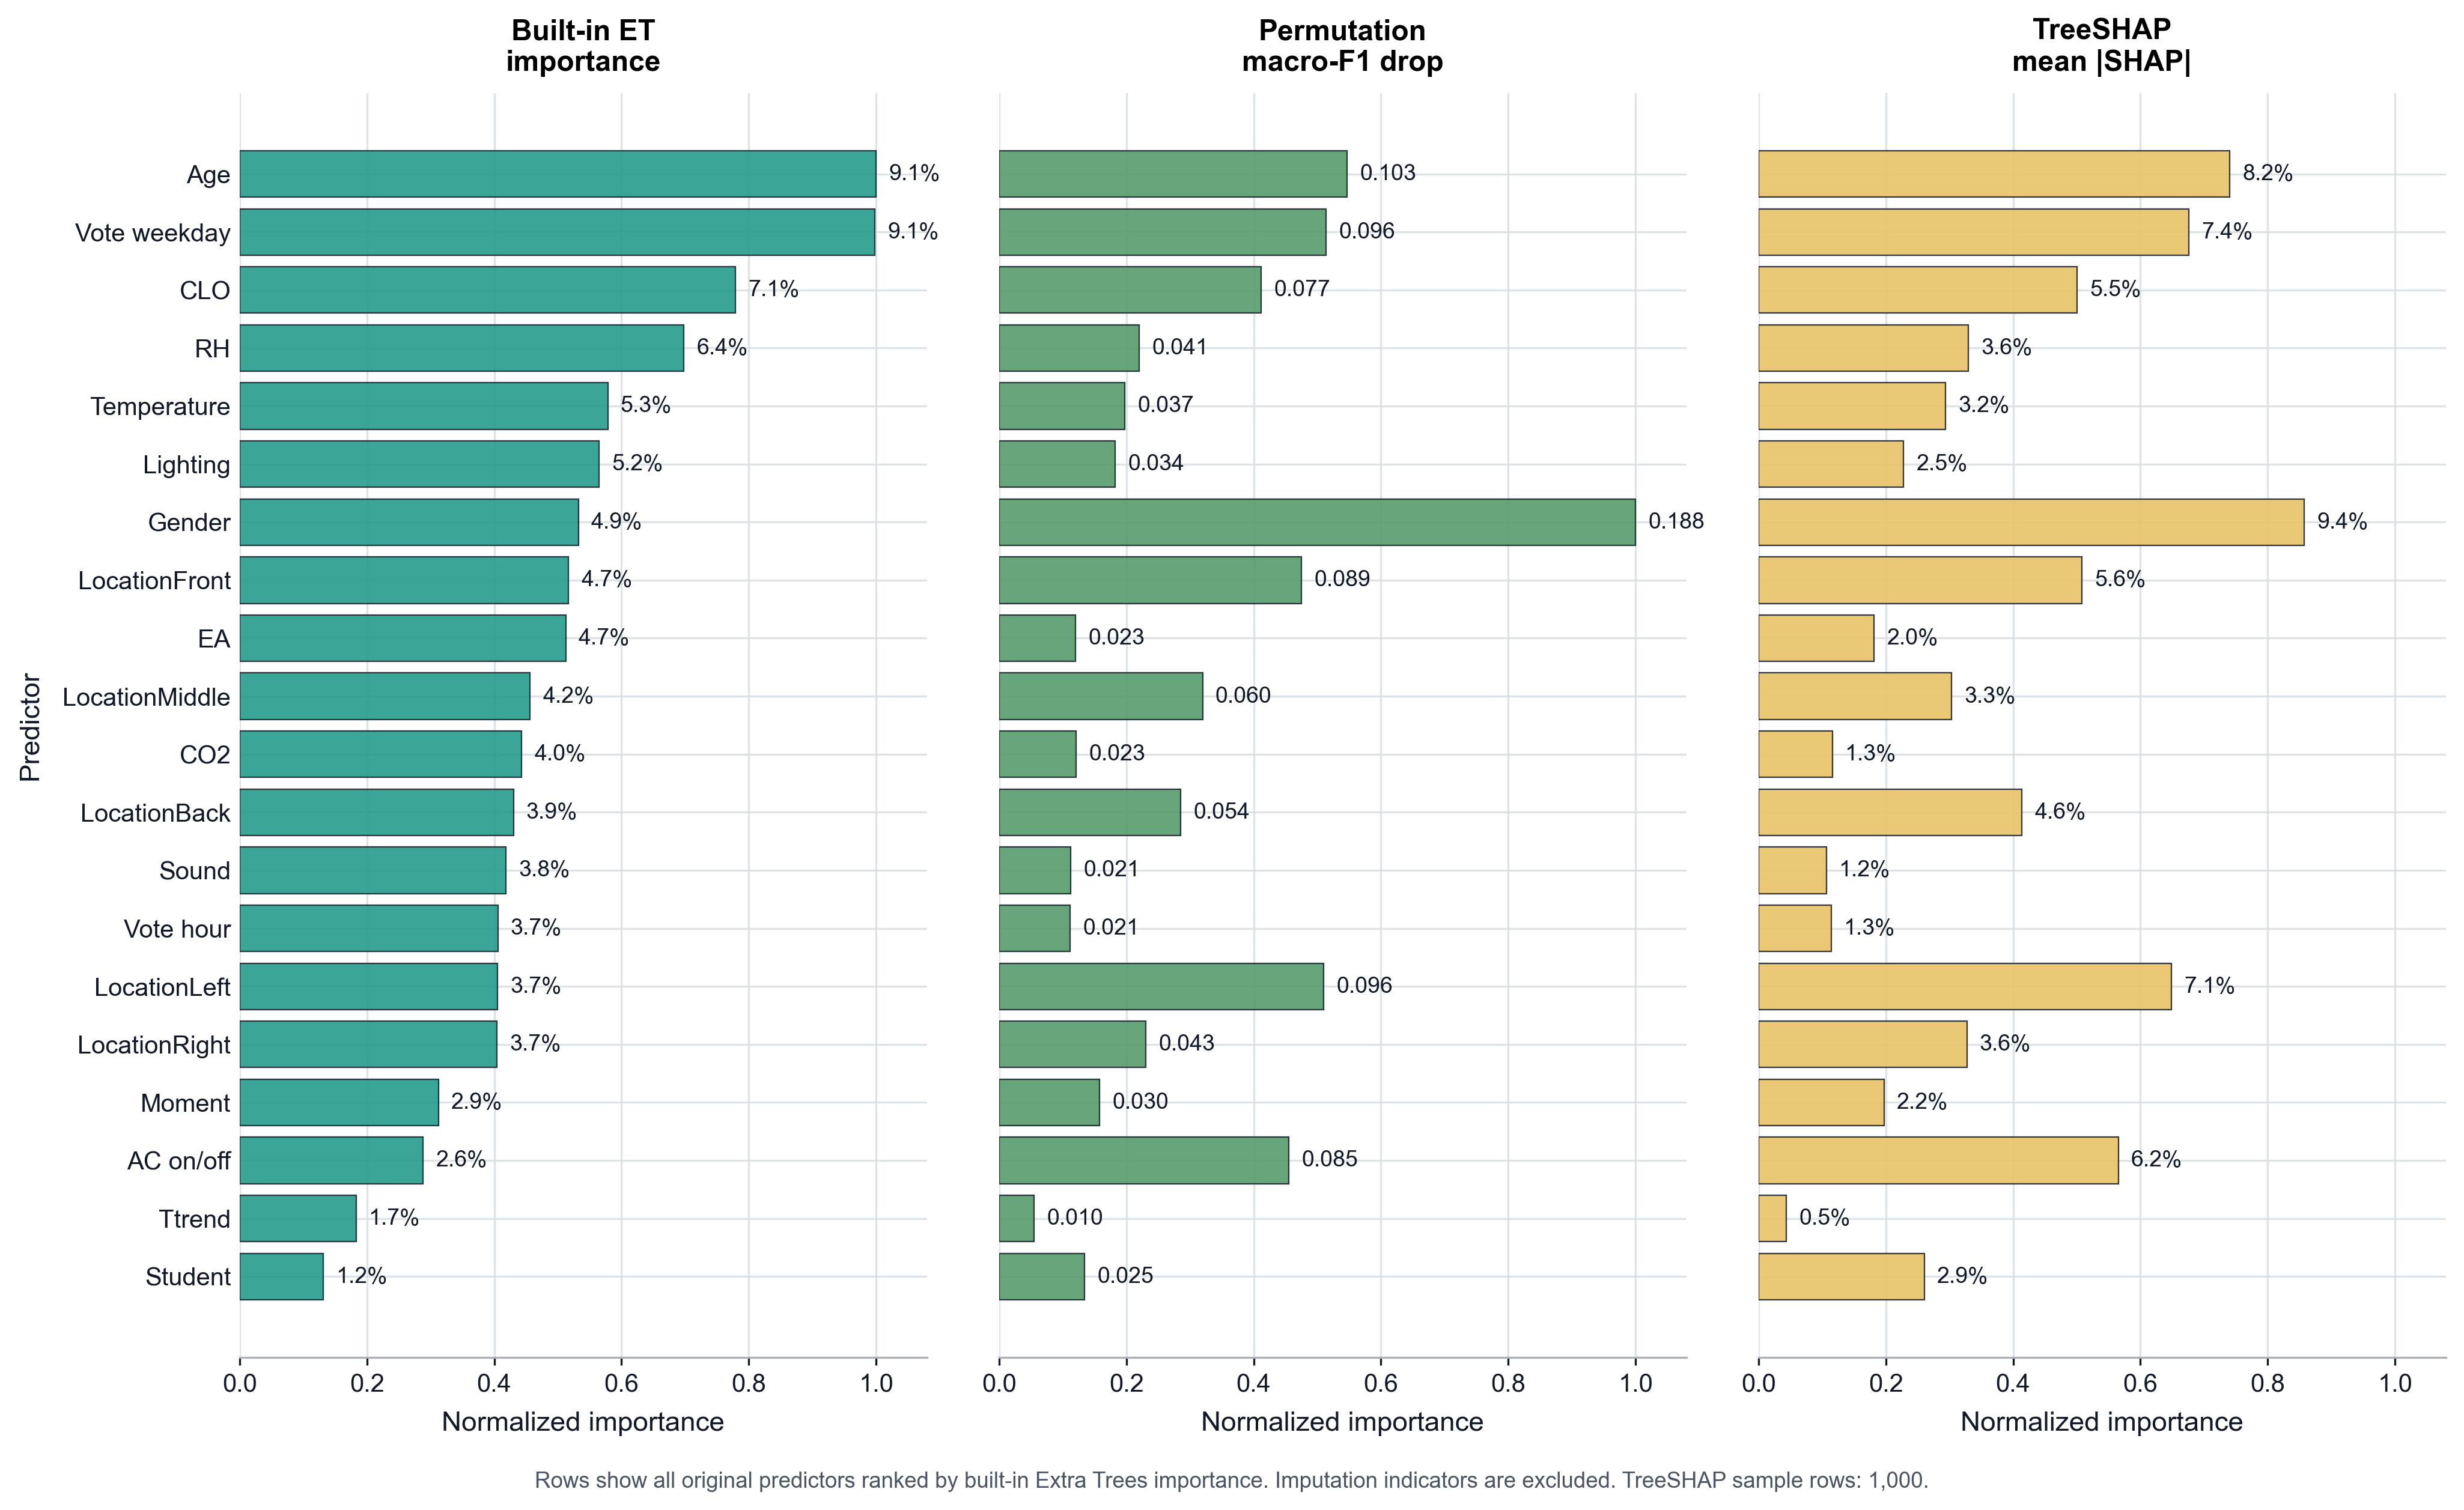

In [12]:
plot_data = article_importance_comparison.head(FEATURE_IMPORTANCE_TOP_N).sort_values("builtin_importance", ascending=True)
method_panels = [
    (
        "builtin_normalized",
        "builtin_importance_percent",
        "Built-in ET\nimportance",
        lambda value: f"{value:.1f}%" if pd.notna(value) else "n/a",
        PAPER_COLORS["best"],
    ),
    (
        "permutation_normalized",
        "permutation_macro_f1_drop_mean",
        "Permutation\nmacro-F1 drop",
        lambda value: f"{value:.3f}" if pd.notna(value) else "n/a",
        PAPER_COLORS["secondary_green"],
    ),
    (
        "shap_normalized",
        "shap_importance_percent",
        "TreeSHAP\nmean |SHAP|",
        lambda value: f"{value:.1f}%" if pd.notna(value) else "n/a",
        PAPER_COLORS["medium"],
    ),
]

fig, axes = plt.subplots(ncols=3, figsize=(13.8, 8.2), sharey=True)
for ax, (normalized_column, raw_column, title, formatter, color) in zip(axes, method_panels):
    bars = ax.barh(
        plot_data["feature"],
        plot_data[normalized_column],
        color=color,
        edgecolor=PAPER_COLORS["border"],
        linewidth=0.55,
        alpha=0.92,
    )
    ax.set_title(title, fontsize=11.5, fontweight="bold", pad=9)
    ax.set_xlim(0, 1.08)
    ax.set_xlabel("Normalized importance", fontsize=11, labelpad=6)
    style_axes(ax, grid_axis="x")
    ax.tick_params(axis="x", labelsize=10)
    ax.tick_params(axis="y", labelsize=10)
    for bar, raw_value in zip(bars, plot_data[raw_column]):
        ax.text(
            bar.get_width() + 0.02,
            bar.get_y() + bar.get_height() / 2,
            formatter(raw_value),
            va="center",
            fontsize=9,
            color=PAPER_COLORS["text"],
        )

axes[0].set_ylabel("Predictor", fontsize=11, labelpad=8)
for ax in axes[1:]:
    ax.tick_params(axis="y", labelleft=False)
fig.text(
    0.5,
    -0.015,
    f"Rows show all original predictors ranked by built-in Extra Trees importance. Imputation indicators are excluded. TreeSHAP sample rows: {shap_sample_rows:,}.",
    ha="center",
    fontsize=8.8,
    color=PAPER_COLORS["muted_text"],
)
fig.tight_layout()

importance_figure_base = FIGURE_DIR / "ieq_final_extra_trees_importance_method_comparison"
paper_importance_figure_base = PAPER_FIGURE_DIR / "final_extra_trees_importance_method_comparison"
save_figure(fig, importance_figure_base)
save_figure(fig, paper_importance_figure_base)
print("Saved feature-importance table:", importance_comparison_path)
print("Saved article feature-importance table:", article_importance_comparison_path)
print("Saved feature-importance figure:", importance_figure_base.with_suffix(".png"))
print("Saved paper feature-importance figure:", paper_importance_figure_base.with_suffix(".pdf"))
plt.show()